<a href="https://colab.research.google.com/github/HuyLuong2002/anfis-breast-cancer/blob/main/anfis_breast_cancer_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Môi trường triển khai

- Hệ điều hành hỗ trợ: Windows, Linux hoặc macOS khi chạy local.
- Ngôn ngữ lập trình: Python 3.8+; khuyến nghị tạo môi trường ảo `.venv` để cô lập phụ thuộc.
- Nền tảng thực thi: Jupyter Notebook hoặc Google Colab.
- Thư viện chính: `numpy`, `pandas`, `scipy`, `scikit-learn`, `matplotlib`, `seaborn`, `torch`, `ucimlrepo` và `scikit-anfis`.
- Cách cài đặt: clone mã nguồn `scikit-anfis`, cài dependencies từ `requirements.txt`, sau đó cài package ở chế độ editable bằng `pip install -e ./scikit-anfis`.

# Cài đặt thư viện



In [6]:
# Chạy cell này trước tiên (hỗ trợ local Windows/Linux/Mac)
import os
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd()
REPO_DIR = PROJECT_ROOT / "scikit-anfis"
VENV_DIR = PROJECT_ROOT / ".venv"

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/hudscomdz/scikit-anfis.git"], check=True)

# Tạo venv local (khuyến nghị để chạy notebook ổn định)
if os.name == "nt":
    venv_python = VENV_DIR / "Scripts" / "python.exe"
else:
    venv_python = VENV_DIR / "bin" / "python"

if not venv_python.exists():
    subprocess.run([sys.executable, "-m", "venv", str(VENV_DIR)], check=True)

# Cài dependencies vào venv
subprocess.run([str(venv_python), "-m", "pip", "install", "--upgrade", "pip"], check=True)
subprocess.run([str(venv_python), "-m", "pip", "install", "-r", str(REPO_DIR / "requirements.txt")], check=True)
subprocess.run([str(venv_python), "-m", "pip", "install", "-e", str(REPO_DIR)], check=True)

# Cài vào kernel hiện tại để notebook import được ngay
%pip install -q pandas numpy scikit-learn scipy matplotlib seaborn ucimlrepo
%pip install -q -e ./scikit-anfis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neural_network import MLPClassifier
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import skanfis
from skanfis.membership import make_gauss_mfs

import warnings
warnings.filterwarnings('ignore')

# Tránh sklearn cố render estimator dạng HTML (gây lỗi với scikit-anfis custom class)
set_config(display="text")

np.random.seed(42)  # Đảm bảo kết quả tái lập được

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Tiền xử lý dữ liệu cho mô hình đề xuất


In [7]:
# =========================
# Cell cấu hình thử nghiệm
# =========================
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
COLUMNS = [
    "ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

TRIAL_TAG = "novel_relief_grid"
RANDOM_STATES = [21, 42, 7, 10, 99]
RANDOM_STATE = RANDOM_STATES[0]  # dùng cho các cell phía sau sau khi chọn best model

SPLIT_CONFIGS = [
    {"preset_name": "RUN_1", "run_note": "Novel Relief + ANFIS - split 80/20", "test_size": 0.2},
    {"preset_name": "RUN_2", "run_note": "Novel Relief + ANFIS - split 70/30", "test_size": 0.3},
    {"preset_name": "RUN_3", "run_note": "Novel Relief + ANFIS - split 60/40", "test_size": 0.4},
]

LEARNING_RATES = [0.01, 0.05, 0.001]
EPOCHS = [25, 50, 75, 100]

TOP_K_FEATURES = 4
RELIEF_SAMPLE_SIZE = 475
RELIEF_THRESHOLD = 0.5
OUTLIER_STD_MULTIPLIER = 3
MICE_MAX_ITER = 10
MEMBERSHIP_FUNCTIONS_PER_FEATURE = 3

# Huấn luyện mô hình

In [8]:
# =========================
# Tiền xử lý + Novel Relief + Mahalanobis + grid thử nghiệm ANFIS
# =========================
from pathlib import Path
from datetime import datetime
import itertools
import json
import pickle

import torch
from torch.utils.data import TensorDataset, DataLoader
from skanfis import scikit_anfis
import skanfis.experimental as anfis_exp

log_dir = Path("nhat-ky")
log_dir.mkdir(parents=True, exist_ok=True)
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
ARTIFACT_BASENAME = f"{RUN_TIMESTAMP}_{TRIAL_TAG}"


def load_wbcd_data():
    df_raw = pd.read_csv(DATA_URL, names=COLUMNS, na_values="?")
    df = df_raw.drop(columns=["ID"]).drop_duplicates().copy()
    df["Class"] = df["Class"].map({2: 0, 4: 1})  # 0: Benign, 1: Malignant
    feature_names = df.drop(columns=["Class"]).columns.tolist()
    X = df[feature_names]
    y = df["Class"].astype(int).to_numpy()
    return df_raw, df, feature_names, X, y


def impute_missing_values_with_mice(X, random_state):
    imputer = IterativeImputer(
        initial_strategy="mean",
        max_iter=MICE_MAX_ITER,
        random_state=random_state,
        min_value=1,
        max_value=10,
    )
    return imputer, imputer.fit_transform(X)


def remove_outliers_with_euclidean_distance(X_imputed):
    data_center = X_imputed.mean(axis=0)
    euclidean_distances = np.linalg.norm(X_imputed - data_center, axis=1)
    outlier_threshold = euclidean_distances.mean() + OUTLIER_STD_MULTIPLIER * euclidean_distances.std()
    outlier_mask = euclidean_distances > outlier_threshold
    return outlier_mask, euclidean_distances, outlier_threshold


def mahalanobis_distance_to_all(target_row, candidate_rows, inv_covariance):
    return cdist(target_row.reshape(1, -1), candidate_rows, metric="mahalanobis", VI=inv_covariance).ravel()


def novel_relief_mahalanobis(X_values, y_values, feature_names, random_state):
    rng = np.random.default_rng(random_state)
    sample_count = min(RELIEF_SAMPLE_SIZE, len(X_values))
    sampled_indices = rng.choice(len(X_values), size=sample_count, replace=False)

    covariance = np.cov(X_values, rowvar=False)
    covariance += np.eye(covariance.shape[0]) * 1e-6
    inv_covariance = np.linalg.pinv(covariance)

    feature_ranges = np.ptp(X_values, axis=0)
    feature_ranges[feature_ranges == 0] = 1
    weights = np.zeros(X_values.shape[1], dtype=float)

    for idx in sampled_indices:
        target_row = X_values[idx]
        target_class = y_values[idx]

        same_class_indices = np.where((y_values == target_class) & (np.arange(len(y_values)) != idx))[0]
        other_class_indices = np.where(y_values != target_class)[0]
        if len(same_class_indices) == 0 or len(other_class_indices) == 0:
            continue

        hit_distances = mahalanobis_distance_to_all(target_row, X_values[same_class_indices], inv_covariance)
        miss_distances = mahalanobis_distance_to_all(target_row, X_values[other_class_indices], inv_covariance)

        nearest_hit = X_values[same_class_indices[np.argmin(hit_distances)]]
        nearest_miss = X_values[other_class_indices[np.argmin(miss_distances)]]

        diff_hit = np.abs(target_row - nearest_hit) / feature_ranges
        diff_miss = np.abs(target_row - nearest_miss) / feature_ranges
        weights += -diff_hit + diff_miss

    relief_scores = weights / sample_count
    score_df = pd.DataFrame({
        "Feature": feature_names,
        "Novel_Relief_score": relief_scores,
    }).sort_values("Novel_Relief_score", ascending=False).reset_index(drop=True)

    selected_by_threshold = score_df[score_df["Novel_Relief_score"] >= RELIEF_THRESHOLD]["Feature"].tolist()
    if len(selected_by_threshold) < TOP_K_FEATURES:
        selected_features = score_df.head(TOP_K_FEATURES)["Feature"].tolist()
    else:
        selected_features = selected_by_threshold[:TOP_K_FEATURES]

    selected_indices = [feature_names.index(feature) for feature in selected_features]
    return selected_features, selected_indices, score_df


def build_anfis_model(X_train_sc, epoch, learning_rate, cfg):
    anfis_input_defs = []
    for feature_idx in range(X_train_sc.shape[1]):
        centers = np.quantile(X_train_sc[:, feature_idx], [0.10, 0.50, 0.90]).tolist()
        sigma = max(float(np.std(X_train_sc[:, feature_idx]) / MEMBERSHIP_FUNCTIONS_PER_FEATURE), 0.10)
        anfis_input_defs.append((f"x{feature_idx}", make_gauss_mfs(sigma, centers)))

    model = scikit_anfis(
        data=anfis_input_defs,
        description=f"Breast Cancer ANFIS - {cfg['preset_name']} - lr={learning_rate} - epoch={epoch}",
        epoch=epoch,
        hybrid=True,
        label="c",
    )
    return model


def fit_anfis_with_learning_rate(model, X_train_sc, y_train, epoch, learning_rate):
    X_tensor = torch.from_numpy(X_train_sc).float()
    y_tensor = torch.from_numpy(y_train).float()
    train_loader = DataLoader(TensorDataset(X_tensor, torch.unsqueeze(y_tensor, -1)), batch_size=1024, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = anfis_exp.RMSELoss()
    anfis_exp.windows = []
    anfis_exp.train_anfis_with(model, train_loader, optimizer, criterion, epochs=epoch, show_plots=False)
    model.load()  # nạp lại epoch có RMSE tốt nhất do train_anfis_with lưu tạm
    return model


def evaluate_predictions(y_true, y_pred):
    y_pred = np.ravel(y_pred).astype(int)
    y_pred = np.clip(y_pred, 0, 1)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Benign", "Malignant"],
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 6),
        "precision_malignant": round(float(report["Malignant"]["precision"]), 6),
        "recall_malignant": round(float(report["Malignant"]["recall"]), 6),
        "f1_malignant": round(float(report["Malignant"]["f1-score"]), 6),
        "macro_f1": round(float(report["macro avg"]["f1-score"]), 6),
        "weighted_f1": round(float(report["weighted avg"]["f1-score"]), 6),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": report,
        "y_pred": y_pred,
    }


# 1) Tiền xử lý theo bài báo: MICE + Euclidean Distance
# 2) Chọn đặc trưng bằng Novel Relief, nearest hit/miss dùng Mahalanobis Distance
# 3) Lặp lại với nhiều random_state để kiểm tra độ ổn định theo yêu cầu thực nghiệm
# Tổng số lần huấn luyện = số seed x 3 split x 3 learning rate x 4 epoch.
df_raw, df, feature_names, X, y = load_wbcd_data()

experiment_rows = []
experiment_objects = []
last_preprocessing_context = {}

for random_state in RANDOM_STATES:
    np.random.seed(random_state)
    torch.manual_seed(random_state)

    imputer, X_imputed_seed = impute_missing_values_with_mice(X, random_state)
    outlier_mask_seed, euclidean_distances_seed, outlier_threshold_seed = remove_outliers_with_euclidean_distance(X_imputed_seed)
    X_clean_seed = X_imputed_seed[~outlier_mask_seed]
    y_clean_seed = y[~outlier_mask_seed]

    train_features_seed, selected_idx_seed, relief_score_df_seed = novel_relief_mahalanobis(
        X_clean_seed,
        y_clean_seed,
        feature_names,
        random_state,
    )
    X_selected_seed = X_clean_seed[:, selected_idx_seed]

    last_preprocessing_context = {
        "imputer": imputer,
        "X_imputed": X_imputed_seed,
        "outlier_mask": outlier_mask_seed,
        "euclidean_distances": euclidean_distances_seed,
        "outlier_threshold": outlier_threshold_seed,
        "X_clean": X_clean_seed,
        "y_clean": y_clean_seed,
        "train_features": train_features_seed,
        "selected_idx": selected_idx_seed,
        "relief_score_df": relief_score_df_seed,
    }

    for split_cfg, learning_rate, epoch in itertools.product(SPLIT_CONFIGS, LEARNING_RATES, EPOCHS):
        cfg = {
            **split_cfg,
            "trial_tag": TRIAL_TAG,
            "random_state": random_state,
            "learning_rate": learning_rate,
            "epoch": epoch,
            "top_k_features": TOP_K_FEATURES,
        }

        X_train, X_test, y_train, y_test = train_test_split(
            X_selected_seed,
            y_clean_seed,
            test_size=cfg["test_size"],
            random_state=cfg["random_state"],
            stratify=y_clean_seed,
        )

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        anfis_model = build_anfis_model(X_train_sc, epoch, learning_rate, cfg)
        anfis_model = fit_anfis_with_learning_rate(anfis_model, X_train_sc, y_train, epoch, learning_rate)
        y_pred_anfis = anfis_model.predict(X_test_sc)
        metrics = evaluate_predictions(y_test, y_pred_anfis)

        experiment_id = len(experiment_rows)
        row = {
            "experiment_id": experiment_id,
            "preset_name": cfg["preset_name"],
            "split": cfg["run_note"].split(" - ")[-1],
            "test_size": cfg["test_size"],
            "random_state": random_state,
            "learning_rate": learning_rate,
            "epoch": epoch,
            "accuracy": metrics["accuracy"],
            "precision_malignant": metrics["precision_malignant"],
            "recall_malignant": metrics["recall_malignant"],
            "f1_malignant": metrics["f1_malignant"],
            "macro_f1": metrics["macro_f1"],
            "weighted_f1": metrics["weighted_f1"],
            "train_samples": len(y_train),
            "test_samples": len(y_test),
            "train_features": ", ".join(train_features_seed),
        }
        experiment_rows.append(row)
        experiment_objects.append({
            "cfg": cfg,
            "model": anfis_model,
            "scaler": scaler,
            "X_train": X_train,
            "X_test": X_test,
            "X_train_sc": X_train_sc,
            "X_test_sc": X_test_sc,
            "y_train": y_train,
            "y_test": y_test,
            "metrics": metrics,
            "train_features": train_features_seed,
            "relief_score_df": relief_score_df_seed,
            "preprocessing_context": last_preprocessing_context,
        })

EXPERIMENT_RESULTS = pd.DataFrame(experiment_rows)

# Tổng hợp độ ổn định: cùng split/lr/epoch được lặp lại trên nhiều random_state.
STABILITY_RESULTS = (
    EXPERIMENT_RESULTS
    .groupby(["preset_name", "split", "test_size", "learning_rate", "epoch"], as_index=False)
    .agg(
        runs=("random_state", "count"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        recall_malignant_mean=("recall_malignant", "mean"),
        recall_malignant_std=("recall_malignant", "std"),
        f1_malignant_mean=("f1_malignant", "mean"),
        f1_malignant_std=("f1_malignant", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
    )
    .fillna(0)
)

BEST_STABLE_CONFIG = STABILITY_RESULTS.sort_values(
    ["accuracy_mean", "recall_malignant_mean", "f1_malignant_mean", "accuracy_std"],
    ascending=[False, False, False, True],
).iloc[0]

best_candidate_rows = EXPERIMENT_RESULTS[
    (EXPERIMENT_RESULTS["preset_name"] == BEST_STABLE_CONFIG["preset_name"]) &
    (EXPERIMENT_RESULTS["test_size"] == BEST_STABLE_CONFIG["test_size"]) &
    (EXPERIMENT_RESULTS["learning_rate"] == BEST_STABLE_CONFIG["learning_rate"]) &
    (EXPERIMENT_RESULTS["epoch"] == BEST_STABLE_CONFIG["epoch"])
].copy()
best_candidate_rows["distance_to_mean_accuracy"] = (best_candidate_rows["accuracy"] - BEST_STABLE_CONFIG["accuracy_mean"]).abs()
BEST_EXPERIMENT_ID = int(
    best_candidate_rows.sort_values(
        ["distance_to_mean_accuracy", "recall_malignant", "f1_malignant"],
        ascending=[True, False, False],
    ).iloc[0]["experiment_id"]
)
BEST_EXPERIMENT = experiment_objects[BEST_EXPERIMENT_ID]

# Gán lại các biến chính để các cell diễn giải/đánh giá phía sau dùng cấu hình đại diện của cấu hình ổn định nhất.
CFG = BEST_EXPERIMENT["cfg"]
model = BEST_EXPERIMENT["model"]
scaler = BEST_EXPERIMENT["scaler"]
X_train = BEST_EXPERIMENT["X_train"]
X_test = BEST_EXPERIMENT["X_test"]
X_train_sc = BEST_EXPERIMENT["X_train_sc"]
X_test_sc = BEST_EXPERIMENT["X_test_sc"]
y_train = BEST_EXPERIMENT["y_train"]
y_test = BEST_EXPERIMENT["y_test"]
y_pred_anfis = BEST_EXPERIMENT["metrics"]["y_pred"]
train_features = BEST_EXPERIMENT["train_features"]
relief_score_df = BEST_EXPERIMENT["relief_score_df"]
preprocessing_context = BEST_EXPERIMENT["preprocessing_context"]
X_imputed = preprocessing_context["X_imputed"]
outlier_mask = preprocessing_context["outlier_mask"]
outlier_threshold = preprocessing_context["outlier_threshold"]
X_clean = preprocessing_context["X_clean"]
y_clean = preprocessing_context["y_clean"]

EXPECTED_RULE_COUNT = MEMBERSHIP_FUNCTIONS_PER_FEATURE ** len(train_features)
model_path = model_dir / f"{ARTIFACT_BASENAME}_best_anfis.pkl"
scaler_path = model_dir / f"{ARTIFACT_BASENAME}_best_scaler.pkl"
meta_path = model_dir / f"{ARTIFACT_BASENAME}_best_meta.json"
results_path = model_dir / f"{ARTIFACT_BASENAME}_grid_results.csv"
stability_path = model_dir / f"{ARTIFACT_BASENAME}_stability_summary.csv"

model.save(str(model_path))
with scaler_path.open("wb") as f:
    pickle.dump(scaler, f)
EXPERIMENT_RESULTS.to_csv(results_path, index=False, encoding="utf-8-sig")
STABILITY_RESULTS.to_csv(stability_path, index=False, encoding="utf-8-sig")

meta = {
    "artifact_basename": ARTIFACT_BASENAME,
    "preset_name": CFG["preset_name"],
    "trial_tag": CFG["trial_tag"],
    "run_note": CFG["run_note"],
    "preprocessing": "drop ID, drop duplicates, MICE imputation, Euclidean Distance outlier removal, Novel Relief + Mahalanobis feature selection, StandardScaler",
    "feature_selection": "Novel Relief with Mahalanobis nearest hit/miss",
    "relief_threshold": RELIEF_THRESHOLD,
    "relief_sample_size": min(RELIEF_SAMPLE_SIZE, len(X_clean)),
    "outlier_method": "Euclidean Distance to data center; threshold = mean + OUTLIER_STD_MULTIPLIER * std",
    "outlier_threshold": float(outlier_threshold),
    "outliers_removed": int(outlier_mask.sum()),
    "model": "ANFIS Hybrid Learning",
    "train_features": train_features,
    "random_states": RANDOM_STATES,
    "total_training_runs": int(len(EXPERIMENT_RESULTS)),
    "test_size": CFG["test_size"],
    "random_state": CFG["random_state"],
    "learning_rate": CFG["learning_rate"],
    "epoch": CFG["epoch"],
    "membership_functions_per_feature": MEMBERSHIP_FUNCTIONS_PER_FEATURE,
    "expected_rule_count": EXPECTED_RULE_COUNT,
    "best_stable_config": {k: (v.item() if hasattr(v, "item") else v) for k, v in BEST_STABLE_CONFIG.to_dict().items()},
    "best_representative_metrics": {k: v for k, v in BEST_EXPERIMENT["metrics"].items() if k not in ["confusion_matrix", "classification_report", "y_pred"]},
    "model_path": str(model_path.resolve()),
    "scaler_path": str(scaler_path.resolve()),
    "grid_results_path": str(results_path.resolve()),
    "stability_summary_path": str(stability_path.resolve()),
}
with meta_path.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"✅ Dữ liệu gốc: {df_raw.shape[0]} mẫu × {df_raw.shape[1]} cột")
print(f"✅ Sau bỏ trùng: {df.shape[0]} mẫu")
print(f"✅ Missing sau MICE: {np.isnan(X_imputed).sum()}")
print(f"✅ Outlier đã loại bằng Euclidean Distance: {outlier_mask.sum()} mẫu")
print(f"✅ Dữ liệu sạch: {X_clean.shape[0]} mẫu")
print(f"✅ Feature dùng để train ({len(train_features)}): {train_features}")
print(f"✅ Random states đã lặp: {RANDOM_STATES}")
print(f"✅ Số lần huấn luyện đã thử: {len(EXPERIMENT_RESULTS)}")
print(
    "🏆 Best stable config: "
    f"{CFG['run_note']} | lr={CFG['learning_rate']} | epoch={CFG['epoch']} | "
    f"accuracy_mean={BEST_STABLE_CONFIG['accuracy_mean']:.4f} | "
    f"accuracy_std={BEST_STABLE_CONFIG['accuracy_std']:.4f}"
)
print(f"✅ Representative run accuracy: {BEST_EXPERIMENT['metrics']['accuracy']}")
print(f"💾 Đã lưu best model: {model_path}")
print(f"💾 Đã lưu bảng grid: {results_path}")
print(f"💾 Đã lưu bảng ổn định: {stability_path}")

display(relief_score_df.style.set_caption("Điểm chọn đặc trưng bằng Novel Relief + Mahalanobis của representative run"))
display(
    STABILITY_RESULTS.sort_values("accuracy_mean", ascending=False)
    .style
    .set_caption("Tổng hợp độ ổn định: trung bình và độ lệch chuẩn qua nhiều random_state")
    .format({
        "accuracy_mean": "{:.4f}",
        "accuracy_std": "{:.4f}",
        "recall_malignant_mean": "{:.4f}",
        "recall_malignant_std": "{:.4f}",
        "f1_malignant_mean": "{:.4f}",
        "f1_malignant_std": "{:.4f}",
        "macro_f1_mean": "{:.4f}",
        "macro_f1_std": "{:.4f}",
    })
)
display(
    EXPERIMENT_RESULTS.sort_values("accuracy", ascending=False)
    .style
    .set_caption("Chi tiết từng lần thử nghiệm ANFIS: random_state × 3 split × 3 learning rate × 4 epoch")
    .format({
        "accuracy": "{:.4f}",
        "precision_malignant": "{:.4f}",
        "recall_malignant": "{:.4f}",
        "f1_malignant": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
    })
)

✅ Dữ liệu gốc: 699 mẫu × 11 cột
✅ Sau bỏ trùng: 463 mẫu
✅ Missing sau MICE: 0
✅ Outlier đã loại bằng Euclidean Distance: 6 mẫu
✅ Dữ liệu sạch: 457 mẫu
✅ Feature dùng để train (4): ['Bare_Nuclei', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Normal_Nucleoli']
✅ Random states đã lặp: [21, 42, 7, 10, 99]
✅ Số lần huấn luyện đã thử: 180
🏆 Best stable config: Novel Relief + ANFIS - split 60/40 | lr=0.001 | epoch=100 | accuracy_mean=0.8962 | accuracy_std=0.0319
✅ Representative run accuracy: 0.901639
💾 Đã lưu best model: models\20260614_104720_novel_relief_grid_best_anfis.pkl
💾 Đã lưu bảng grid: models\20260614_104720_novel_relief_grid_grid_results.csv
💾 Đã lưu bảng ổn định: models\20260614_104720_novel_relief_grid_stability_summary.csv


,Feature,Novel_Relief_score
0,Bare_Nuclei,0.227226
1,Uniformity_Cell_Size,0.172867
2,Uniformity_Cell_Shape,0.168976
3,Normal_Nucleoli,0.166059
4,Clump_Thickness,0.162169
5,Marginal_Adhesion,0.136154
6,Bland_Chromatin,0.127401
7,Single_Epithelial_Cell_Size,0.069536
8,Mitoses,0.024799


,preset_name,split,test_size,learning_rate,epoch,runs,accuracy_mean,accuracy_std,recall_malignant_mean,recall_malignant_std,f1_malignant_mean,f1_malignant_std,macro_f1_mean,macro_f1_std
27,RUN_3,split 60/40,0.400000,0.001000,100,5,0.8962,0.0319,0.9140,0.0423,0.8992,0.0320,0.8961,0.0318
10,RUN_1,split 80/20,0.200000,0.050000,75,5,0.8696,0.0700,0.8213,0.1070,0.8634,0.0752,0.8692,0.0702
35,RUN_3,split 60/40,0.400000,0.050000,100,5,0.8612,0.0585,0.7871,0.1489,0.8460,0.0798,0.8590,0.0616
23,RUN_2,split 70/30,0.300000,0.050000,100,5,0.8594,0.0601,0.7800,0.1402,0.8436,0.0794,0.8574,0.0627
11,RUN_1,split 80/20,0.200000,0.050000,100,5,0.8565,0.0417,0.8468,0.0932,0.8560,0.0466,0.8561,0.0414
34,RUN_3,split 60/40,0.400000,0.050000,75,5,0.8339,0.0917,0.7484,0.1791,0.8119,0.1210,0.8307,0.0960
22,RUN_2,split 70/30,0.300000,0.050000,75,5,0.8159,0.0681,0.6771,0.1710,0.7785,0.1075,0.8094,0.0763
33,RUN_3,split 60/40,0.400000,0.050000,50,5,0.8087,0.1321,0.6839,0.2842,0.7538,0.2210,0.7960,0.1544
9,RUN_1,split 80/20,0.200000,0.050000,50,5,0.8065,0.1228,0.7617,0.2492,0.7812,0.1827,0.8009,0.1341
7,RUN_1,split 80/20,0.200000,0.010000,100,5,0.7848,0.1750,0.6723,0.3942,0.6856,0.3863,0.7528,0.2427


,experiment_id,preset_name,split,test_size,random_state,learning_rate,epoch,accuracy,precision_malignant,recall_malignant,f1_malignant,macro_f1,weighted_f1,train_samples,test_samples,train_features
157,157,RUN_2,split 70/30,0.300000,99,0.010000,50,0.9493,0.9437,0.9571,0.9504,0.9493,0.9493,319,138,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
160,160,RUN_2,split 70/30,0.300000,99,0.050000,25,0.9493,0.9437,0.9571,0.9504,0.9493,0.9493,319,138,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
156,156,RUN_2,split 70/30,0.300000,99,0.010000,25,0.9493,0.9437,0.9571,0.9504,0.9493,0.9493,319,138,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
154,154,RUN_1,split 80/20,0.200000,99,0.001000,75,0.9457,0.9200,0.9787,0.9485,0.9455,0.9456,365,92,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
148,148,RUN_1,split 80/20,0.200000,99,0.050000,25,0.9457,0.9200,0.9787,0.9485,0.9455,0.9456,365,92,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
144,144,RUN_1,split 80/20,0.200000,99,0.010000,25,0.9457,0.9200,0.9787,0.9485,0.9455,0.9456,365,92,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
150,150,RUN_1,split 80/20,0.200000,99,0.050000,75,0.9457,0.9200,0.9787,0.9485,0.9455,0.9456,365,92,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
146,146,RUN_1,split 80/20,0.200000,99,0.010000,75,0.9457,0.9200,0.9787,0.9485,0.9455,0.9456,365,92,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
152,152,RUN_1,split 80/20,0.200000,99,0.001000,25,0.9457,0.9200,0.9787,0.9485,0.9455,0.9456,365,92,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"
175,175,RUN_3,split 60/40,0.400000,99,0.050000,100,0.9344,0.9175,0.9570,0.9368,0.9343,0.9344,274,183,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli"


In [9]:
# Xuất thêm CSV để vẽ biểu đồ lại sau này
# - raw_results: từng run theo random_state x split x learning_rate x epoch
# - plot_ready_results: dữ liệu đã gộp theo split/lr/epoch, kèm mean/std qua các random state
# - random_state_manifest: danh sách random state đã dùng trong grid search

raw_results_path = model_dir / f"{ARTIFACT_BASENAME}_raw_results.csv"
plot_ready_results_path = model_dir / f"{ARTIFACT_BASENAME}_plot_ready_results.csv"
random_state_manifest_path = model_dir / f"{ARTIFACT_BASENAME}_random_states.csv"

EXPERIMENT_RESULTS.to_csv(raw_results_path, index=False, encoding="utf-8-sig")
STABILITY_RESULTS.to_csv(plot_ready_results_path, index=False, encoding="utf-8-sig")
pd.DataFrame({"random_state": RANDOM_STATES}).to_csv(random_state_manifest_path, index=False, encoding="utf-8-sig")

print(f"✅ Đã lưu raw results: {raw_results_path}")
print(f"✅ Đã lưu plot-ready results: {plot_ready_results_path}")
print(f"✅ Đã lưu random state manifest: {random_state_manifest_path}")

✅ Đã lưu raw results: models\20260614_104720_novel_relief_grid_raw_results.csv
✅ Đã lưu plot-ready results: models\20260614_104720_novel_relief_grid_plot_ready_results.csv
✅ Đã lưu random state manifest: models\20260614_104720_novel_relief_grid_random_states.csv


# Cấu hình ANFIS ổn định nhất từ grid search

Cell phía trên đã huấn luyện ANFIS bằng Hybrid Learning cho toàn bộ tổ hợp nhiều random state, 3 cách chia dữ liệu, 3 learning rate và 4 giá trị epoch. Cell này xác nhận cấu hình ổn định nhất theo trung bình accuracy qua nhiều lần lặp, đồng thời chọn một lần chạy đại diện để các phần diễn giải/đánh giá phía sau sử dụng cùng một mô hình.

In [10]:
# Xác nhận mô hình tốt nhất đã được chọn từ grid search
print("✅ Mô hình: ANFIS Hybrid Learning")
print("✅ Feature selection: Novel Relief + Mahalanobis")
print("✅ Features:", train_features)
print("✅ Membership functions/feature:", MEMBERSHIP_FUNCTIONS_PER_FEATURE)
print("✅ Expected fuzzy rules:", EXPECTED_RULE_COUNT)
print("✅ Best stable split:", CFG["run_note"])
print("✅ Best stable learning rate:", CFG["learning_rate"])
print("✅ Best stable epoch:", CFG["epoch"])
print("✅ Random states:", RANDOM_STATES)
print("✅ Train/Test representative:", X_train_sc.shape, X_test_sc.shape)
print("✅ Accuracy mean:", round(float(BEST_STABLE_CONFIG["accuracy_mean"]), 6))
print("✅ Accuracy std:", round(float(BEST_STABLE_CONFIG["accuracy_std"]), 6))
print("✅ Recall malignant mean:", round(float(BEST_STABLE_CONFIG["recall_malignant_mean"]), 6))
print("✅ Recall malignant std:", round(float(BEST_STABLE_CONFIG["recall_malignant_std"]), 6))
print("✅ Representative accuracy:", BEST_EXPERIMENT["metrics"]["accuracy"])
print("✅ Representative recall malignant:", BEST_EXPERIMENT["metrics"]["recall_malignant"])

✅ Mô hình: ANFIS Hybrid Learning
✅ Feature selection: Novel Relief + Mahalanobis
✅ Features: ['Bare_Nuclei', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Normal_Nucleoli']
✅ Membership functions/feature: 3
✅ Expected fuzzy rules: 81
✅ Best stable split: Novel Relief + ANFIS - split 60/40
✅ Best stable learning rate: 0.001
✅ Best stable epoch: 100
✅ Random states: [21, 42, 7, 10, 99]
✅ Train/Test representative: (274, 4) (183, 4)
✅ Accuracy mean: 0.896175
✅ Accuracy std: 0.031863
✅ Recall malignant mean: 0.913978
✅ Recall malignant std: 0.042334
✅ Representative accuracy: 0.901639
✅ Representative recall malignant: 0.946237


# Diễn giải ANFIS bằng luật mờ

Phần này làm rõ điểm khác biệt chính giữa ANFIS và Neural Network truyền thống: ANFIS không chỉ đưa ra nhãn dự đoán mà còn cho phép xem dữ liệu được mờ hóa, các luật mờ được kích hoạt, mức độ kích hoạt từng luật và diễn giải vì sao mẫu được dự đoán là Benign hoặc Malignant.

Với 4 feature đầu vào và mỗi feature có 3 mức mờ `Thấp`, `Trung bình`, `Cao`, tổng số luật mờ là `3^4 = 81`.

In [11]:
# Diễn giải ANFIS: mờ hóa dữ liệu, luật mờ, suy diễn và mẫu dự đoán sai
import json
import torch

CLASS_LABELS = {0: "Benign", 1: "Malignant"}
EXPLAIN_SAMPLE_LIMIT = 6
TOP_RULES_PER_SAMPLE = 5
BUSINESS_LABELS_BY_COUNT = {
    2: ["Thấp", "Cao"],
    3: ["Thấp", "Trung bình", "Cao"],
}

var_mfs = model.layer["fuzzify"].varmfs
feature_by_var = {var_name: train_features[i] for i, var_name in enumerate(var_mfs.keys())}


def get_center_value(mf_def):
    """Lấy tâm hàm thành viên để gán nhãn thấp/cao."""
    if hasattr(mf_def, "mu"):
        return float(mf_def.mu.detach().cpu().item())
    if hasattr(mf_def, "c"):
        return float(mf_def.c.detach().cpu().item())
    if hasattr(mf_def, "b"):
        return float(mf_def.b.detach().cpu().item())
    return np.nan


def get_param_value(mf_def, param_name):
    if hasattr(mf_def, param_name):
        return float(getattr(mf_def, param_name).detach().cpu().item())
    return np.nan


mf_business_label = {}
mf_rows = []
for feature_idx, (var_name, fuzz_var) in enumerate(var_mfs.items()):
    mf_centers = [
        (mf_name, get_center_value(mf_def))
        for mf_name, mf_def in fuzz_var.mfdefs.items()
    ]
    sorted_mfs = sorted(mf_centers, key=lambda item: item[1])
    business_labels = BUSINESS_LABELS_BY_COUNT.get(
        len(sorted_mfs),
        [f"Mức_{rank + 1}" for rank in range(len(sorted_mfs))],
    )
    label_map = {
        mf_name: business_labels[rank]
        for rank, (mf_name, _) in enumerate(sorted_mfs)
    }
    mf_business_label[var_name] = label_map

    for mf_name, mf_def in fuzz_var.mfdefs.items():
        center_scaled = get_center_value(mf_def)
        sigma_scaled = get_param_value(mf_def, "sigma")
        center_original = center_scaled * scaler.scale_[feature_idx] + scaler.mean_[feature_idx]
        mf_rows.append({
            "feature": feature_by_var[var_name],
            "biến_trong_mô_hình": var_name,
            "membership": mf_name,
            "nhãn_nghiệp_vụ": label_map[mf_name],
            "tâm_sau_chuẩn_hóa": round(center_scaled, 4),
            "độ_rộng_sigma": round(sigma_scaled, 4),
            "tâm_xấp_xỉ_trên_thang_gốc": round(float(center_original), 4),
        })

membership_df = pd.DataFrame(mf_rows)
display(
    membership_df.style
    .set_caption("1) Các hàm thành viên mờ sau huấn luyện: mf0/mf1/mf2 được diễn giải thành Thấp/Trung bình/Cao")
    .format({
        "tâm_sau_chuẩn_hóa": "{:.4f}",
        "độ_rộng_sigma": "{:.4f}",
        "tâm_xấp_xỉ_trên_thang_gốc": "{:.4f}",
    })
)

# Chạy forward trực tiếp để giữ đúng thứ tự mẫu test và lấy các tầng trung gian của ANFIS.
# scikit-anfis có cờ is_training riêng; cần tắt để forward không gọi fit_coeff khi không có y_actual.
model.eval()
model.is_training = False
X_test_tensor = torch.from_numpy(X_test_sc).float()
with torch.no_grad():
    anfis_score = model(X_test_tensor).detach().cpu().numpy().reshape(-1)

fuzzified_values = model.fuzzified.detach().cpu().numpy()
rule_fire_strength = model.raw_weights.detach().cpu().numpy()
rule_weight = model.weights.detach().cpu().numpy()
rule_output = model.rule_tsk.detach().cpu().numpy().squeeze(1)
y_pred_anfis_explain = np.clip(np.rint(np.abs(anfis_score)), 0, 1).astype(int)

# 1 mẫu sẽ được tách thành nhiều dòng: mỗi dòng là mức thuộc mờ của 1 feature.
fuzzy_rows = []
for sample_pos in range(min(10, len(X_test_sc))):
    for feature_idx, (var_name, fuzz_var) in enumerate(var_mfs.items()):
        mf_names = list(fuzz_var.mfdefs.keys())
        degrees = fuzzified_values[sample_pos, feature_idx, :len(mf_names)]
        dominant_idx = int(np.argmax(degrees))
        row = {
            "mẫu_test": sample_pos,
            "thực_tế": CLASS_LABELS[int(y_test[sample_pos])],
            "ANFIS_dự_đoán": CLASS_LABELS[int(y_pred_anfis_explain[sample_pos])],
            "điểm_ANFIS": round(float(anfis_score[sample_pos]), 4),
            "feature": feature_by_var[var_name],
            "giá_trị_gốc": round(float(X_test[sample_pos, feature_idx]), 4),
            "giá_trị_sau_chuẩn_hóa": round(float(X_test_sc[sample_pos, feature_idx]), 4),
            "mức_mờ_trội": mf_business_label[var_name][mf_names[dominant_idx]],
        }
        for mf_name, degree in zip(mf_names, degrees):
            label = mf_business_label[var_name][mf_name]
            row[f"độ_thuộc_{label}"] = round(float(degree), 4)
        fuzzy_rows.append(row)

fuzzy_data_df = pd.DataFrame(fuzzy_rows)
fuzzy_format = {
    col: "{:.4f}"
    for col in fuzzy_data_df.columns
    if col.startswith("độ_thuộc_") or col in ["điểm_ANFIS", "giá_trị_gốc", "giá_trị_sau_chuẩn_hóa"]
}
display(
    fuzzy_data_df.style
    .set_caption("2) Dữ liệu test sau khi được mờ hóa: mỗi feature có độ thuộc Thấp/Trung bình/Cao")
    .format(fuzzy_format)
)

# Danh sách luật: với 4 feature và 3 membership/feature sẽ có 3^4 = 81 luật.
rule_indices = model.layer["rules"].mf_indices.detach().cpu().numpy()
actual_rule_count = int(len(rule_indices))
expected_rule_count = int(np.prod([len(fuzz_var.mfdefs) for fuzz_var in var_mfs.values()]))
print(f"✅ Số luật mờ thực tế: {actual_rule_count} = {MEMBERSHIP_FUNCTIONS_PER_FEATURE}^{len(train_features)}")
if actual_rule_count != expected_rule_count:
    print(f"⚠️ Số luật thực tế ({actual_rule_count}) khác số luật kỳ vọng ({expected_rule_count}).")
rule_rows = []
for rule_idx, mf_idx_by_feature in enumerate(rule_indices):
    conditions = []
    for feature_idx, mf_idx in enumerate(mf_idx_by_feature):
        var_name = list(var_mfs.keys())[feature_idx]
        mf_name = list(var_mfs[var_name].mfdefs.keys())[int(mf_idx)]
        conditions.append(f"{feature_by_var[var_name]} {mf_business_label[var_name][mf_name]}")

    mean_output = float(np.mean(rule_output[:, rule_idx]))
    dominant_class = 1 if mean_output >= 0.5 else 0
    rule_rows.append({
        "luật": f"R{rule_idx + 1}",
        "IF": " AND ".join(conditions),
        "THEN_nghiêng_về": CLASS_LABELS[dominant_class],
        "đầu_ra_Sugeno_trung_bình": round(mean_output, 4),
        "độ_kích_hoạt_tb": round(float(np.mean(rule_weight[:, rule_idx])), 4),
        "độ_kích_hoạt_lớn_nhất": round(float(np.max(rule_weight[:, rule_idx])), 4),
        "số_lần_là_luật_mạnh_nhất": int(np.sum(np.argmax(rule_weight, axis=1) == rule_idx)),
    })

fuzzy_rules_df = pd.DataFrame(rule_rows)
display(
    fuzzy_rules_df.sort_values("số_lần_là_luật_mạnh_nhất", ascending=False).style
    .set_caption("3) Các luật mờ của ANFIS và mức độ được kích hoạt trên tập test")
    .format({
        "đầu_ra_Sugeno_trung_bình": "{:.4f}",
        "độ_kích_hoạt_tb": "{:.4f}",
        "độ_kích_hoạt_lớn_nhất": "{:.4f}",
    })
)

# Ưu tiên giải thích các mẫu ANFIS dự đoán sai; nếu ít mẫu sai thì thêm vài mẫu đúng để minh họa.
wrong_sample_positions = np.where(y_pred_anfis_explain != y_test)[0].tolist()
correct_sample_positions = np.where(y_pred_anfis_explain == y_test)[0].tolist()
samples_to_explain = (wrong_sample_positions + correct_sample_positions)[:EXPLAIN_SAMPLE_LIMIT]

sample_summary_rows = []
rule_trace_rows = []
rule_text_by_id = fuzzy_rules_df.set_index("luật")["IF"].to_dict()
for sample_pos in samples_to_explain:
    status = "Sai" if y_pred_anfis_explain[sample_pos] != y_test[sample_pos] else "Đúng"
    top_rule_indices = np.argsort(rule_weight[sample_pos])[::-1][:TOP_RULES_PER_SAMPLE]
    top_rule_names = [f"R{i + 1}" for i in top_rule_indices]
    sample_summary_rows.append({
        "mẫu_test": int(sample_pos),
        "kết_quả": status,
        "thực_tế": CLASS_LABELS[int(y_test[sample_pos])],
        "ANFIS_dự_đoán": CLASS_LABELS[int(y_pred_anfis_explain[sample_pos])],
        "điểm_ANFIS": round(float(anfis_score[sample_pos]), 4),
        "các_luật_tác_động_mạnh": ", ".join(top_rule_names),
    })
    for rank, rule_idx in enumerate(top_rule_indices, start=1):
        rule_name = f"R{rule_idx + 1}"
        contribution = float(rule_weight[sample_pos, rule_idx] * rule_output[sample_pos, rule_idx])
        rule_trace_rows.append({
            "mẫu_test": int(sample_pos),
            "xếp_hạng_luật": rank,
            "luật": rule_name,
            "điều_kiện_luật": rule_text_by_id[rule_name],
            "độ_kích_hoạt_chuẩn_hóa": round(float(rule_weight[sample_pos, rule_idx]), 4),
            "đầu_ra_luật_Sugeno": round(float(rule_output[sample_pos, rule_idx]), 4),
            "đóng_góp_vào_điểm_cuối": round(contribution, 4),
        })

sample_summary_df = pd.DataFrame(sample_summary_rows)
rule_trace_df = pd.DataFrame(rule_trace_rows)

display(
    sample_summary_df.style
    .set_caption("4) Các mẫu được giải thích: ưu tiên mẫu ANFIS dự đoán sai")
    .format({"điểm_ANFIS": "{:.4f}"})
)

display(
    rule_trace_df.style
    .set_caption("5) Suy diễn chi tiết: mỗi mẫu dựa mạnh nhất trên các luật nào")
    .format({
        "độ_kích_hoạt_chuẩn_hóa": "{:.4f}",
        "đầu_ra_luật_Sugeno": "{:.4f}",
        "đóng_góp_vào_điểm_cuối": "{:.4f}",
    })
)

print("✅ Tóm tắt diễn giải ANFIS")
print(f"- Số luật mờ: {len(fuzzy_rules_df)}")
print(f"- Số mẫu test ANFIS dự đoán sai: {len(wrong_sample_positions)} / {len(y_test)}")
print(f"- Các mẫu đang giải thích: {samples_to_explain}")
print("- Cách đọc: độ kích hoạt càng cao thì luật đó càng ảnh hưởng mạnh tới điểm ANFIS của mẫu.")

top_rules_for_meta = json.loads(
    fuzzy_rules_df
    .sort_values("số_lần_là_luật_mạnh_nhất", ascending=False)
    .head(5)
    .to_json(orient="records", force_ascii=False)
)
ANFIS_INTERPRETABILITY = {
    "rule_count": int(len(fuzzy_rules_df)),
    "misclassified_test_samples": int(len(wrong_sample_positions)),
    "explained_test_sample_positions": [int(x) for x in samples_to_explain],
    "top_rules_by_activation": top_rules_for_meta,
}

if "meta_path" in globals():
    if meta_path.exists():
        with meta_path.open("r", encoding="utf-8") as f:
            meta = json.load(f)
    else:
        meta = {}
    meta["anfis_interpretability"] = ANFIS_INTERPRETABILITY
    with meta_path.open("w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"🗂️ Đã cập nhật phần diễn giải ANFIS vào metadata: {meta_path}")

,feature,biến_trong_mô_hình,membership,nhãn_nghiệp_vụ,tâm_sau_chuẩn_hóa,độ_rộng_sigma,tâm_xấp_xỉ_trên_thang_gốc
0,Bare_Nuclei,x0,mf0,Thấp,-0.9204,0.3844,1.1598
1,Bare_Nuclei,x0,mf1,Trung bình,-0.4349,0.2835,3.0155
2,Bare_Nuclei,x0,mf2,Cao,1.4153,0.2990,10.0882
3,Uniformity_Cell_Size,x1,mf0,Thấp,-1.0144,0.2874,0.8895
4,Uniformity_Cell_Size,x1,mf1,Trung bình,-0.3718,0.2730,2.8994
5,Uniformity_Cell_Size,x1,mf2,Cao,1.8468,0.3840,9.8378
6,Uniformity_Cell_Shape,x2,mf0,Thấp,-0.9710,0.3811,1.1869
7,Uniformity_Cell_Shape,x2,mf1,Trung bình,-0.3484,0.2984,3.0585
8,Uniformity_Cell_Shape,x2,mf2,Cao,1.6102,0.3445,8.9460
9,Normal_Nucleoli,x3,mf0,Thấp,-0.7641,0.3554,1.0863


,mẫu_test,thực_tế,ANFIS_dự_đoán,điểm_ANFIS,feature,giá_trị_gốc,giá_trị_sau_chuẩn_hóa,mức_mờ_trội,độ_thuộc_Thấp,độ_thuộc_Trung bình,độ_thuộc_Cao
0,0,Malignant,Malignant,1.0824,Bare_Nuclei,10.0000,1.3922,Cao,0.0000,0.0000,0.9970
1,0,Malignant,Malignant,1.0824,Uniformity_Cell_Size,6.0000,0.6197,Cao,0.0000,0.0014,0.0061
2,0,Malignant,Malignant,1.0824,Uniformity_Cell_Shape,5.0000,0.2975,Trung bình,0.0039,0.0961,0.0007
3,0,Malignant,Malignant,1.0824,Normal_Nucleoli,1.0000,-0.7911,Thấp,0.9971,0.6418,0.0000
4,1,Malignant,Malignant,1.5753,Bare_Nuclei,4.0000,-0.1774,Trung bình,0.1544,0.6619,0.0000
5,1,Malignant,Malignant,1.5753,Uniformity_Cell_Size,10.0000,1.8987,Cao,0.0000,0.0000,0.9909
6,1,Malignant,Malignant,1.5753,Uniformity_Cell_Shape,6.0000,0.6301,Cao,0.0001,0.0046,0.0175
7,1,Malignant,Malignant,1.5753,Normal_Nucleoli,10.0000,2.0322,Cao,0.0000,0.0000,0.9452
8,2,Malignant,Malignant,1.0000,Bare_Nuclei,10.0000,1.3922,Cao,0.0000,0.0000,0.9970
9,2,Malignant,Malignant,1.0000,Uniformity_Cell_Size,5.0000,0.2999,Trung bình,0.0000,0.0485,0.0003


✅ Số luật mờ thực tế: 81 = 3^4


,luật,IF,THEN_nghiêng_về,đầu_ra_Sugeno_trung_bình,độ_kích_hoạt_tb,độ_kích_hoạt_lớn_nhất,số_lần_là_luật_mạnh_nhất
0,R1,Bare_Nuclei Thấp AND Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Thấp,Malignant,8.0521,0.1121,0.4436,36
80,R81,Bare_Nuclei Cao AND Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Normal_Nucleoli Cao,Malignant,0.9998,0.1103,1.0000,22
27,R28,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Thấp,Benign,-30.4263,0.0450,0.4445,10
1,R2,Bare_Nuclei Thấp AND Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Trung bình,Malignant,7.9507,0.0854,0.5156,9
9,R10,Bare_Nuclei Thấp AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Thấp,Benign,-21.3817,0.0278,0.4523,9
67,R68,Bare_Nuclei Cao AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Trung bình,Benign,0.1098,0.0434,0.7449,9
53,R54,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Normal_Nucleoli Cao,Benign,-0.3767,0.0473,0.8503,9
3,R4,Bare_Nuclei Thấp AND Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Thấp,Malignant,2.3314,0.0355,0.4386,8
68,R69,Bare_Nuclei Cao AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Cao,Malignant,0.5823,0.0412,0.9486,8
26,R27,Bare_Nuclei Thấp AND Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Normal_Nucleoli Cao,Malignant,1.9721,0.0369,0.8486,7


,mẫu_test,kết_quả,thực_tế,ANFIS_dự_đoán,điểm_ANFIS,các_luật_tác_động_mạnh
0,8,Sai,Benign,Malignant,2.0031,"R12, R15, R39, R42, R3"
1,16,Sai,Benign,Malignant,1.2569,"R37, R38, R40, R10, R41"
2,37,Sai,Benign,Malignant,0.7982,"R12, R39, R15, R3, R42"
3,46,Sai,Malignant,Benign,-0.4788,"R40, R31, R41, R32, R13"
4,51,Sai,Malignant,Benign,-0.0918,"R69, R60, R66, R57, R68"
5,52,Sai,Benign,Malignant,1.5290,"R80, R79, R77, R71, R53"


,mẫu_test,xếp_hạng_luật,luật,điều_kiện_luật,độ_kích_hoạt_chuẩn_hóa,đầu_ra_luật_Sugeno,đóng_góp_vào_điểm_cuối
0,8,1,R12,Bare_Nuclei Thấp AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Cao,0.4534,0.9827,0.4456
1,8,2,R15,Bare_Nuclei Thấp AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Cao,0.2907,0.5122,0.1489
2,8,3,R39,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Cao,0.0809,2.8131,0.2276
3,8,4,R42,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Cao,0.0519,13.1816,0.6838
4,8,5,R3,Bare_Nuclei Thấp AND Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Cao,0.0290,-0.1036,-0.0030
5,16,1,R37,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Thấp,0.2392,-10.1503,-2.4280
6,16,2,R38,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Trung bình,0.1540,54.7153,8.4241
7,16,3,R40,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Thấp,0.1534,-2.5731,-0.3947
8,16,4,R10,Bare_Nuclei Thấp AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Normal_Nucleoli Thấp,0.1092,-4.4537,-0.4863
9,16,5,R41,Bare_Nuclei Trung bình AND Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Normal_Nucleoli Trung bình,0.0987,-12.1055,-1.1952


✅ Tóm tắt diễn giải ANFIS
- Số luật mờ: 81
- Số mẫu test ANFIS dự đoán sai: 18 / 183
- Các mẫu đang giải thích: [8, 16, 37, 46, 51, 52]
- Cách đọc: độ kích hoạt càng cao thì luật đó càng ảnh hưởng mạnh tới điểm ANFIS của mẫu.
🗂️ Đã cập nhật phần diễn giải ANFIS vào metadata: models\20260614_104720_novel_relief_grid_best_meta.json


# Đánh giá và so sánh với Neural Network truyền thống

Phần này dùng cùng tập train/test và cùng dữ liệu đã chuẩn hóa để so sánh công bằng giữa ANFIS Hybrid Learning và mạng neural truyền thống dạng MLP.

# Huấn luyện Neural Network truyền thống

Cell này dùng MLPClassifier làm baseline neural network truyền thống, chạy trên cùng dữ liệu train/test đã chuẩn hóa với ANFIS.

In [12]:
# Huấn luyện Neural Network truyền thống
nn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=CFG["random_state"],
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
)

nn_model.fit(X_train_sc, y_train)
y_pred_nn = nn_model.predict(X_test_sc)

print("✅ Huấn luyện Neural Network MLP xong.")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn, target_names=["Benign", "Malignant"], zero_division=0))

✅ Huấn luyện Neural Network MLP xong.
✅ Accuracy: 0.9289617486338798
              precision    recall  f1-score   support

      Benign       0.95      0.90      0.93        90
   Malignant       0.91      0.96      0.93        93

    accuracy                           0.93       183
   macro avg       0.93      0.93      0.93       183
weighted avg       0.93      0.93      0.93       183




📈 Kết quả tập Test - ANFIS Hybrid Learning
✅ Accuracy: 90.16%
              precision    recall  f1-score   support

      Benign       0.94      0.86      0.90        90
   Malignant       0.87      0.95      0.91        93

    accuracy                           0.90       183
   macro avg       0.91      0.90      0.90       183
weighted avg       0.90      0.90      0.90       183


📈 Kết quả tập Test - Neural Network MLP
✅ Accuracy: 92.90%
              precision    recall  f1-score   support

      Benign       0.95      0.90      0.93        90
   Malignant       0.91      0.96      0.93        93

    accuracy                           0.93       183
   macro avg       0.93      0.93      0.93       183
weighted avg       0.93      0.93      0.93       183



,model,accuracy,precision_malignant,recall_malignant,f1_malignant,macro_f1,weighted_f1,train_features,test_size
0,ANFIS Hybrid Learning,0.9016,0.8713,0.9462,0.9072,0.9013,0.9014,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli",0.400000
1,Neural Network MLP,0.9290,0.9082,0.9570,0.9319,0.9288,0.9289,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli",0.400000


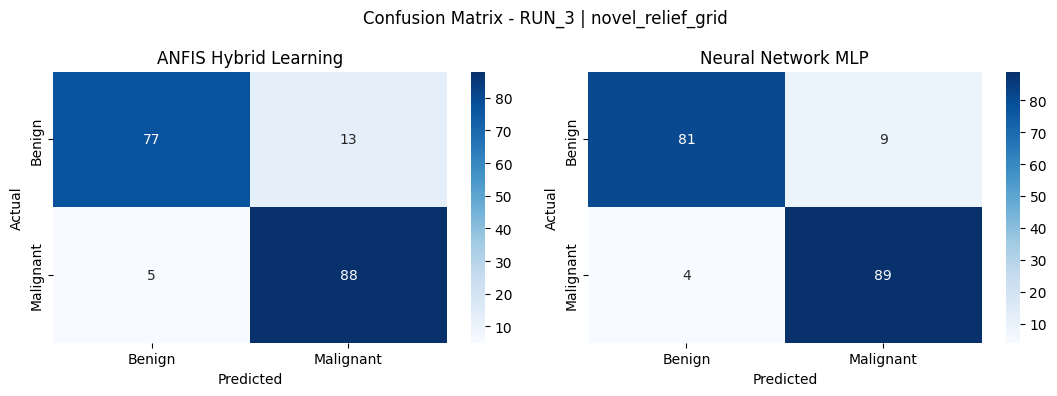

,preset_name,trial_tag,run_note,comparison_goal,anfis_accuracy,nn_accuracy,best_model_by_accuracy,test_size,learning_rate,epoch,top_k_features,train_features,preprocessing
0,RUN_3,novel_relief_grid,Novel Relief + ANFIS - split 60/40,ANFIS Hybrid Learning vs Neural Network truyền thống,0.901639,0.928962,Neural Network MLP,0.400000,0.001000,100,4,"Bare_Nuclei, Uniformity_Cell_Size, Uniformity_Cell_Shape, Normal_Nucleoli",MICE imputation + Euclidean Distance outlier removal + Novel Relief + Mahalanobis + StandardScaler


💾 Đã lưu Neural Network baseline: models\20260614_104720_novel_relief_grid_neural_network_mlp.pkl
🗂️ Đã cập nhật kết quả so sánh vào metadata: models\20260614_104720_novel_relief_grid_best_meta.json


In [13]:
# Đánh giá ANFIS Hybrid Learning và Neural Network truyền thống

def summarize_metrics(model_name, y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=['Benign', 'Malignant'],
        output_dict=True,
        zero_division=0,
    )
    cm_value = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 6),
        "precision_malignant": round(float(report['Malignant']['precision']), 6),
        "recall_malignant": round(float(report['Malignant']['recall']), 6),
        "f1_malignant": round(float(report['Malignant']['f1-score']), 6),
        "macro_f1": round(float(report['macro avg']['f1-score']), 6),
        "weighted_f1": round(float(report['weighted avg']['f1-score']), 6),
        "confusion_matrix": cm_value,
        "classification_report": report,
    }

# 1. ANFIS Hybrid Learning
# Dùng dự đoán đã lưu từ BEST_EXPERIMENT để tránh model.predict() nạp nhầm tmp.pkl của lần train cuối trong grid search.
y_pred_anfis = np.asarray(BEST_EXPERIMENT["metrics"]["y_pred"]).astype(int)
anfis_result = summarize_metrics("ANFIS Hybrid Learning", y_test, y_pred_anfis)

# 2. Neural Network truyền thống đã được huấn luyện ở cell trước
y_pred_nn = nn_model.predict(X_test_sc)
nn_result = summarize_metrics("Neural Network MLP", y_test, y_pred_nn)

for result, y_pred_current in [(anfis_result, y_pred_anfis), (nn_result, y_pred_nn)]:
    print("\n" + "=" * 70)
    print(f"📈 Kết quả tập Test - {result['model']}")
    print("=" * 70)
    print(f"✅ Accuracy: {result['accuracy'] * 100:.2f}%")
    print(classification_report(y_test, y_pred_current, target_names=['Benign', 'Malignant'], zero_division=0))

comparison_rows = []
for result in [anfis_result, nn_result]:
    comparison_rows.append({
        "model": result["model"],
        "accuracy": result["accuracy"],
        "precision_malignant": result["precision_malignant"],
        "recall_malignant": result["recall_malignant"],
        "f1_malignant": result["f1_malignant"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "train_features": ", ".join(train_features),
        "test_size": CFG["test_size"],
    })

comparison_df = pd.DataFrame(comparison_rows)
display(
    comparison_df.style
    .set_caption("📌 So sánh ANFIS Hybrid Learning với Neural Network truyền thống")
    .format({
        "accuracy": "{:.4f}",
        "precision_malignant": "{:.4f}",
        "recall_malignant": "{:.4f}",
        "f1_malignant": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, result in zip(axes, [anfis_result, nn_result]):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Benign', 'Malignant'],
        yticklabels=['Benign', 'Malignant'],
        ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(result["model"])
plt.suptitle(f"Confusion Matrix - {CFG['preset_name']} | {CFG['trial_tag']}")
plt.tight_layout()
plt.show()

RUN_RESULT = {
    "preset_name": CFG["preset_name"],
    "trial_tag": CFG["trial_tag"],
    "run_note": CFG["run_note"],
    "comparison_goal": "ANFIS Hybrid Learning vs Neural Network truyền thống",
    "anfis_accuracy": anfis_result["accuracy"],
    "nn_accuracy": nn_result["accuracy"],
    "best_model_by_accuracy": comparison_df.sort_values("accuracy", ascending=False).iloc[0]["model"],
    "test_size": CFG["test_size"],
    "learning_rate": CFG["learning_rate"],
    "epoch": CFG["epoch"],
    "top_k_features": CFG["top_k_features"],
    "train_features": ", ".join(train_features),
    "preprocessing": "MICE imputation + Euclidean Distance outlier removal + Novel Relief + Mahalanobis + StandardScaler",
}

display(pd.DataFrame([RUN_RESULT]).style.set_caption("📌 Tóm tắt kết quả run hiện tại"))

# Lưu baseline Neural Network và cập nhật metadata để truy vết kết quả so sánh
import json
import pickle

nn_model_path = model_dir / f"{ARTIFACT_BASENAME}_neural_network_mlp.pkl"
with nn_model_path.open("wb") as f:
    pickle.dump(nn_model, f)

if "meta_path" not in globals():
    meta_path = model_dir / f"{ARTIFACT_BASENAME}_best_meta.json"

if meta_path.exists():
    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)
else:
    meta = {}

meta["comparison_goal"] = "ANFIS Hybrid Learning vs Neural Network truyền thống"
meta["anfis"] = {
    "accuracy": anfis_result["accuracy"],
    "confusion_matrix": anfis_result["confusion_matrix"].tolist(),
    "classification_report": anfis_result["classification_report"],
}
meta["neural_network_mlp"] = {
    "accuracy": nn_result["accuracy"],
    "confusion_matrix": nn_result["confusion_matrix"].tolist(),
    "classification_report": nn_result["classification_report"],
    "model_path": str(nn_model_path.resolve()),
    "hidden_layer_sizes": [16, 8],
}
meta["support"] = {"test_samples": int(len(y_test))}

with meta_path.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"💾 Đã lưu Neural Network baseline: {nn_model_path}")
print(f"🗂️ Đã cập nhật kết quả so sánh vào metadata: {meta_path}")

# Convert HTML

In [14]:
from datetime import datetime

html_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
html_trial_tag = "novel_relief_grid"
html_split_tag = "Novel_Relief_ANFIS_-_split_60_40"
html_output_name = f"{html_timestamp}_{html_trial_tag}_{html_split_tag}.html"
!jupyter nbconvert --to html anfis_breast_cancer_model_training.ipynb --output {html_output_name} --output-dir ./nhat-ky

[NbConvertApp] Converting notebook anfis_breast_cancer_model_training.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 885712 bytes to nhat-ky\20260614_105609_novel_relief_grid_Novel_Relief_ANFIS_-_split_60_40.html
